In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [4]:
data = load_iris()
iris = pd.DataFrame(data.data, columns=data.feature_names)
iris['target'] = data.target  # Add species labels

In [5]:
print("First 5 rows:")
print(iris.head())  # Show the first 5 rows
print("\nStatistical Summary:")
print(iris.describe())  # Show mean, min, max, etc.

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000   

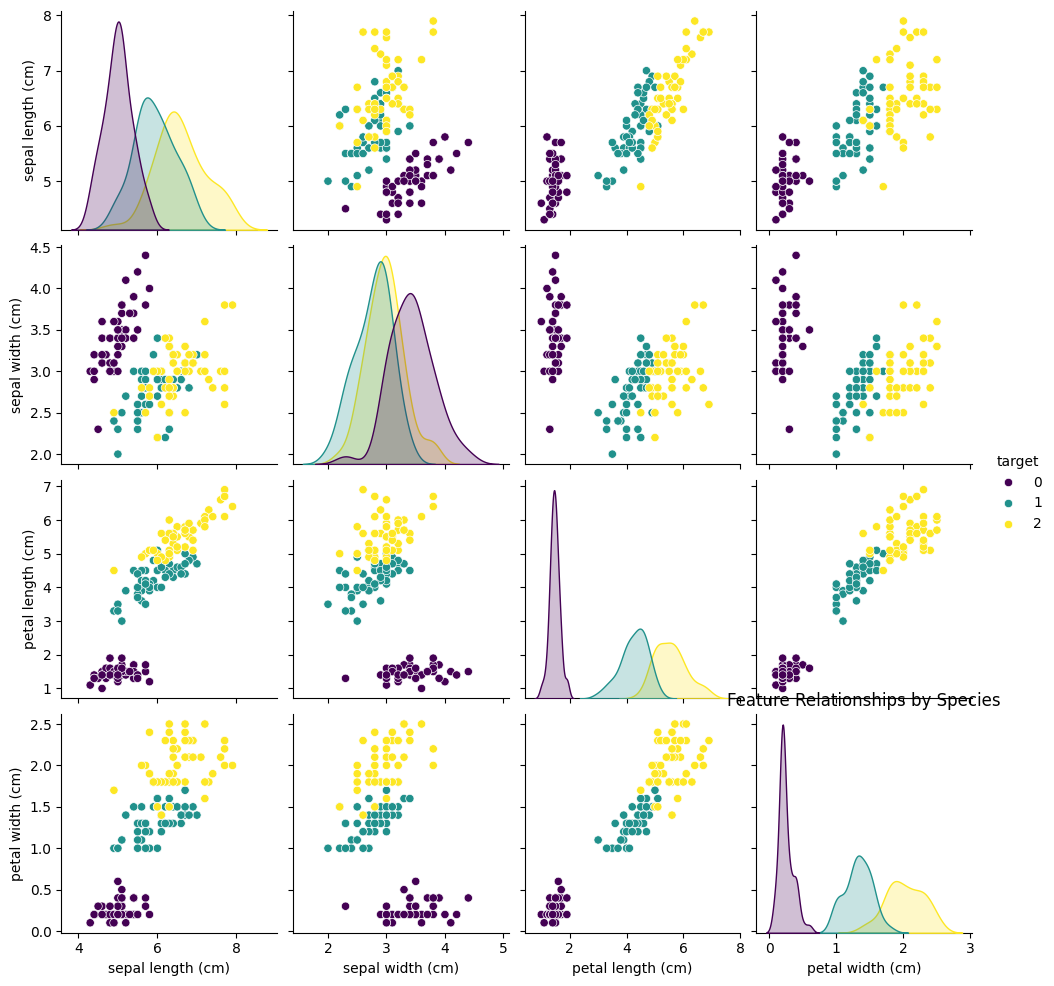

In [6]:
sns.pairplot(iris, hue='target', palette='viridis')
plt.title("Feature Relationships by Species")
plt.show()

In [8]:
X = iris.drop('target', axis=1)  # Features (measurements)
y = iris['target']  # Target (species label)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)  # Teach the model using training data

LogisticRegression(max_iter=200)

In [10]:
y_pred = model.predict(X_test)  # Predict species for test data
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")  # Accuracy score

Accuracy: 1.00


In [11]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



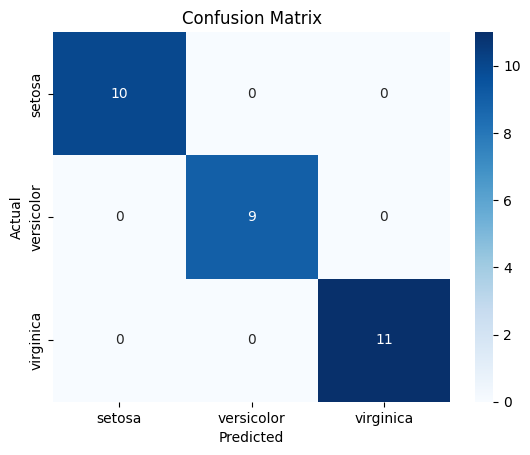

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
new_data = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example flower measurements
prediction = model.predict(new_data)
print(f"Predicted Class: {data.target_names[prediction][0]}")

Predicted Class: setosa


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
